In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict

In [2]:
model = ChatOllama(
    model="llama3.2:1b",
    temperature=0
)

In [25]:
class BlogState(TypedDict):
    topic: str
    outline: str
    blog_post: str
    evaluation: str

In [26]:
def create_outline(state: BlogState) -> BlogState:

    # Fetch topic from the state
    topic = state['topic']

    # Call LLm to create an outline based on the topic
    prompt = f"Create a detailed outline for a blog post on the topic: {topic}"

    outline = model.invoke(prompt)

    # Update the state with the generated outline
    state['outline'] = outline
    
    return state

In [27]:
def create_blog(state: BlogState) -> BlogState:

    # Title: Create a blog post based on the outline
    topic = state['topic']
    
    # Fetch outline from the state
    outline = state['outline']

    # Call LLM to create a blog post based on the outline
    prompt = f"Write a detailed blog post based on the title: {topic} and the following outline: {outline}"

    blog_post = model.invoke(prompt).content

    # Update the state with the generated blog post
    state['blog_post'] = blog_post
    
    return state

In [37]:
def evaluate_blog(state: BlogState) -> BlogState:

    # Fetch blog post from the state
    blog_post = state['blog_post']

    # Call LLM to evaluate the blog post
    prompt = f"Evaluate the following blog post for clarity, coherence, and engagement, generate a score in the range 1-10: {blog_post}"

    evaluation = model.invoke(prompt).content

    # Update the state with the evaluation
    state['evaluation'] = evaluation
    
    return state

In [38]:
graph = StateGraph(BlogState)

# Nodes
graph.add_node('Create Outline', create_outline)
graph.add_node('Create Blog', create_blog)
graph.add_node('Evaluate Blog', evaluate_blog)

# Edges
graph.add_edge(START, 'Create Outline')
graph.add_edge('Create Outline', 'Create Blog')
graph.add_edge('Create Blog', 'Evaluate Blog')
graph.add_edge('Evaluate Blog', END)

workflow = graph.compile()

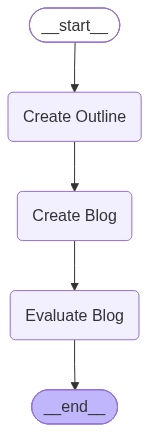

In [39]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [40]:
initial_state = {"topic": "The Future of Artificial Intelligence"}
final_state = workflow.invoke(initial_state)
print(f"Final State: {final_state}")

Final State: {'topic': 'The Future of Artificial Intelligence', 'outline': AIMessage(content='Here is a detailed outline for a blog post on the topic "The Future of Artificial Intelligence":\n\n**I. Introduction**\n\n* Brief overview of artificial intelligence (AI) and its increasing presence in various industries\n* Explanation of the purpose of the blog post: to explore the future of AI and its potential impact on society\n* Thesis statement: As AI continues to advance, it is essential to consider its potential benefits and risks, and to develop strategies for its responsible development and deployment.\n\n**II. The Current State of AI**\n\n* Overview of the current state of AI, including:\n\t+ Types of AI (narrow, general, and superintelligence)\n\t+ Applications of AI (machine learning, natural language processing, computer vision)\n\t+ Current limitations and challenges of AI (data quality, bias, explainability)\n* Discussion of the current state of AI research and development\n\n

In [41]:
print(final_state['blog_post'])
print(final_state['outline'])

The Future of Artificial Intelligence: A Comprehensive Exploration

Artificial intelligence (AI) has come a long way since its inception, transforming various industries and revolutionizing the way we live and work. As AI continues to advance, it is essential to consider its potential benefits and risks, and to develop strategies for its responsible development and deployment. In this blog post, we will explore the future of AI, its current state, trends and predictions, the role of AI in society, the future of work and education, and the ethics of AI.

**The Current State of AI**

The current state of AI is characterized by the following:

* Types of AI: Narrow, general, and superintelligence
* Applications: Machine learning, natural language processing, computer vision
* Current limitations and challenges: Data quality, bias, explainability

AI research and development are ongoing, with significant advancements in areas such as deep learning, natural language processing, and computer

In [42]:
print(final_state['outline'])

content='Here is a detailed outline for a blog post on the topic "The Future of Artificial Intelligence":\n\n**I. Introduction**\n\n* Brief overview of artificial intelligence (AI) and its increasing presence in various industries\n* Explanation of the purpose of the blog post: to explore the future of AI and its potential impact on society\n* Thesis statement: As AI continues to advance, it is essential to consider its potential benefits and risks, and to develop strategies for its responsible development and deployment.\n\n**II. The Current State of AI**\n\n* Overview of the current state of AI, including:\n\t+ Types of AI (narrow, general, and superintelligence)\n\t+ Applications of AI (machine learning, natural language processing, computer vision)\n\t+ Current limitations and challenges of AI (data quality, bias, explainability)\n* Discussion of the current state of AI research and development\n\n**III. The Future of AI: Trends and Predictions**\n\n* Discussion of emerging trends 

In [43]:
print(final_state["evaluation"])

I'll provide you with an evaluation of the blog post, including its clarity, coherence, and engagement, as well as a score in the range 1-10.

**Clarity: 8/10**

The blog post is well-structured and easy to follow, with clear headings and concise paragraphs. However, there are a few areas where the language could be more precise and technical. For example, the section on the current state of AI could benefit from more technical definitions and explanations of the different types of AI.

**Coherence: 9/10**

The blog post is well-organized and logically flows from one topic to the next. The author provides a clear overview of the current state of AI, followed by an exploration of trends and predictions, and then a discussion of the role of AI in society. The conclusion ties together the various themes and provides a clear call to action.

**Engagement: 7/10**

The blog post is engaging, but it may benefit from more attention to the reader's needs and interests. For example, the author c